# _**MNIST Digit Recognition with K-Nearest Neighbors**_


## _Dataset_

_This project uses the MNIST dataset in CSV format_.

_Dataset source:_
https://github.com/phoebetronic/mnist

_Required files:_
- mnist_train.csv
- mnist_test.csv

_After downloading the dataset, place both files in the project directory before running the notebook_.

_Note: To reduce computation time, only 10,000 samples from the original 60,000 training images were used in the experiments_.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mglearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

## _Data Loading_

In [2]:
df_train=pd.read_csv("mnist_train.csv",header=None)
df_test=pd.read_csv("mnist_test.csv",header=None)
print(df_train.columns[:10])
print(df_test.columns[:10])
#Time to load data for train data is about 5 seconds


Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')
Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')


_Dataset Dimensions_

In [3]:
df_train.columns.size

785

### _Preparing Features and Labels_

In [4]:
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]

X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 784), (60000,), (10000, 784), (10000,))

## _Data Visualization_

Axes(0.125,0.53;0.133621x0.35)
Axes(0.285345,0.53;0.133621x0.35)
Axes(0.44569,0.53;0.133621x0.35)
Axes(0.606034,0.53;0.133621x0.35)
Axes(0.766379,0.53;0.133621x0.35)
Axes(0.125,0.11;0.133621x0.35)
Axes(0.285345,0.11;0.133621x0.35)
Axes(0.44569,0.11;0.133621x0.35)
Axes(0.606034,0.11;0.133621x0.35)
Axes(0.766379,0.11;0.133621x0.35)


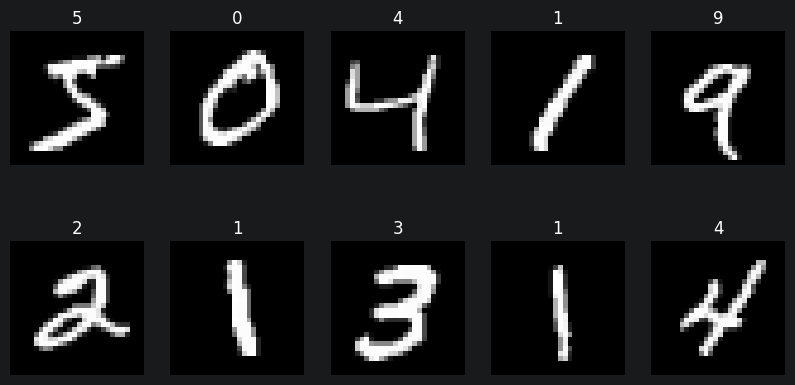

In [5]:
fig, axes = plt.subplots(2,5, figsize=(10,5))
#-------------axes-----------
for i in axes.flat:
    print(i)
#----------------------------
for i, ax in enumerate(axes.flatten()):
    ax.imshow(
        X_train.iloc[i].values.reshape(28,28),
        cmap='gray'
    )
    ax.set_title(y_train.iloc[i])
    ax.axis('off')

plt.show()

#### _Flattening the input — why 28×28 becomes 784_
* _Row by row, each row's elements come one after another, all in order_
* _flat_index = row × number_of_cols + col_

In [6]:
import numpy as np
img = np.array([[1,  2,  3,  4],
                [5,  6,  7,  8],
                [9, 10, 11, 12]])
print(img.flatten())

[ 1  2  3  4  5  6  7  8  9 10 11 12]


#### _**Data Preprocessing and Feature Scaling**_

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

### _Training Subset Selection_
* _To reduce computational cost and training time, a subset of 10,000 samples was selected from the original 60,000 training images. All subsequent experiments were performed using this reduced training set._

In [8]:
from sklearn.model_selection import train_test_split

x_train_small, _, y_train_small, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=10000,
    stratify=y_train,
    random_state=42
)

#### _KNN Performance for Different K Values_

In [9]:
from sklearn.metrics import accuracy_score
accuracies = []
for i in range(1,11):
    model=KNeighborsClassifier(n_neighbors=i,weights="distance",metric="manhattan",algorithm="brute")
    model.fit(x_train_small,y_train_small)
    y_hat=model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test.values,y_hat))
accuracies


[0.9275,
 0.9275,
 0.9328,
 0.9334,
 0.9306,
 0.9306,
 0.9277,
 0.9272,
 0.9258,
 0.9264]

## _Experimental Results and Analysis_

#### _Search Algorithm Comparison_

_The Auto algorithm completed in approximately 1–2 minutes, while the Brute Force algorithm required about 1 minute. In contrast, the KD-Tree algorithm took more than 9 minutes to complete._

_Although Auto is designed to automatically select the most appropriate search strategy, it did not provide a significant speed advantage over Brute Force on the MNIST dataset. Since MNIST is a high-dimensional dataset with 784 features per sample (28×28 pixels), Auto likely selected a search strategy similar to Brute Force. The small difference in execution time may be attributed to implementation overhead and normal runtime variations._

_Based on the experimental results, KD-Tree was significantly slower than both Auto and Brute Force. While KD-Tree performs efficiently on low-dimensional datasets, its effectiveness decreases as the number of dimensions increases. In high-dimensional spaces, the tree structure becomes less efficient at pruning irrelevant points, resulting in longer search times. Therefore, for datasets such as MNIST, Auto and Brute Force are generally more suitable choices than KD-Tree. This experiment demonstrates the impact of the **curse of dimensionality** on nearest-neighbor search algorithms._


### _Final Model Comparison_

In [10]:
acc_distance_euclidean=[0.9091, 0.9091, 0.9156, 0.919, 0.9151, 0.9159, 0.9124, 0.9137, 0.91, 0.9102]
acc_uniform_euclidean=[0.9091, 0.8998, 0.9123, 0.9107, 0.9119, 0.9093, 0.909, 0.9085, 0.9064, 0.9061]
acc_distance_manhattan=[0.9275,0.9275,0.9328,0.9334,0.9306,0.9306,0.9277,0.9272,0.9258,0.9264]
acc_distance_cosine=[0.9093, 0.9093, 0.9132, 0.9177, 0.9133, 0.9154, 0.9131, 0.9141, 0.914, 0.9137]
acc_distance_chebyshev=[0.6948, 0.694, 0.7035, 0.7076, 0.7017, 0.7021, 0.6996, 0.6972, 0.6954, 0.6913]
comparison = pd.DataFrame({
    "Model": [
        "Uniform + Euclidean",
        "Distance + Euclidean",
        "Distance + Manhattan",
        "Distance + Cosine",
        "Distance + Chebyshev"
    ],
    "Best Accuracy": [
        max(acc_uniform_euclidean),
        max(acc_distance_euclidean),
        max(acc_distance_manhattan),
        max(acc_distance_cosine),
        max(acc_distance_chebyshev)
    ]
})

comparison.sort_values(
    by="Best Accuracy",
    ascending=False
)

,Model,Best Accuracy
2,Distance + Manhattan,0.9334
1,Distance + Euclidean,0.9190
3,Distance + Cosine,0.9177
0,Uniform + Euclidean,0.9123
4,Distance + Chebyshev,0.7076


### _Accuracy vs K_


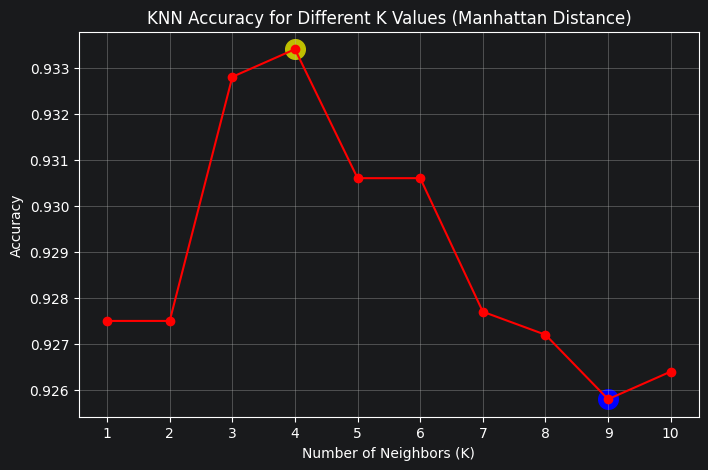

In [11]:
k_values = np.arange(1, 11)
best_k = np.argmax(acc_distance_manhattan) + 1
best_acc = max(acc_distance_manhattan)
worst_k = np.argmin(acc_distance_manhattan) + 1
worst_acc = min(acc_distance_manhattan)
plt.figure(figsize=(8, 5))
plt.plot(k_values, acc_distance_manhattan, marker='o',color="r")
plt.scatter(best_k, best_acc, s=200,color="y")
plt.scatter(worst_k, worst_acc, s=200,color="b")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values (Manhattan Distance)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

_The highest accuracy (93.34%) was achieved when K = 4 using Manhattan distance and distance weighting. As K increased beyond 4, the model performance slightly decreased, suggesting that a small number of neighbors was more effective for the MNIST dataset._

### _Discussion_

The experimental results demonstrate that both the distance metric and weighting scheme have a significant impact on KNN performance. Among all tested configurations, Distance weighting combined with the Manhattan distance metric achieved the highest accuracy of 93.34%, making it the best-performing model.

The Euclidean and Cosine distance metrics produced similar results, achieving best accuracies of 91.90% and 91.77%, respectively. While Cosine distance measures the similarity of vector directions, Euclidean distance considers the actual geometric distance between samples. For the MNIST dataset, which consists of grayscale pixel intensities, considering the magnitude of pixel differences appears to be beneficial for classification performance.

The Chebyshev distance metric performed substantially worse than the other metrics, achieving a best accuracy of only 70.76%. This behavior is expected because Chebyshev distance considers only the maximum difference among all features. Since each MNIST image contains 784 pixel features, focusing on a single largest difference ignores a significant amount of useful information contained in the remaining pixels.

The superior performance of Manhattan distance can be explained by the high-dimensional nature of the MNIST dataset. With 784 features per sample, Manhattan distance often performs well because it measures the sum of feature-wise differences and can be less sensitive to the effects of high dimensionality than Euclidean distance. Overall, the results indicate that Distance weighting with the Manhattan distance metric is the most effective KNN configuration among those evaluated in this study.


## _Conclusion_

_Among all evaluated configurations, Distance weighting with the Manhattan distance metric achieved the highest accuracy (93.34%). The results also showed that KD-Tree was not suitable for the high-dimensional MNIST dataset, while Auto and Brute Force provided much faster execution times. Overall, Manhattan distance combined with distance weighting was the most effective KNN configuration in this study._